In [3]:
from blazy import iphreeqc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from uncertainties.unumpy import nominal_values as noms

/home/oscar/GitHub/blazy/blazy/phreeqc/montecarlo.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [4]:
compositions = pd.read_pickle('Data/vaterite_processed.pkl')
compositions.solution_start.head()

Quantity,B,B/C,C,Ca,Mg,Mg/Ca,Na,Na/Ca,Sr,Sr/Ca,pH_NBS
Instrument,Agilent,calc,dissolution,Agilent,Agilent,calc,Agilent,calc,Agilent,calc,electrode
Unit,mmol,mol/mol,mmol,mmol,mmol,mol/mol,mmol,mol/mol,mmol,mol/mol,Unnamed: 29_level_3
15,0.0101+/-0.0005,0.00202+/-0.00010,5,12.8+/-0.6,-0.00143+/-0.00007,-0.000111+/-0.000008,0.248+/-0.012,0.0193+/-0.0014,0.00101+/-0.00005,(7.9+/-0.6)e-05,8.213
16,0.0452+/-0.0023,0.0090+/-0.0005,5,12.2+/-0.6,1.03+/-0.05,0.084+/-0.006,0.225+/-0.011,0.0184+/-0.0013,0.00096+/-0.00005,(7.9+/-0.6)e-05,8.209
17,0.0185+/-0.0009,0.00370+/-0.00018,5,10.7+/-0.5,2.07+/-0.10,0.193+/-0.014,0.233+/-0.012,0.0218+/-0.0015,0.00087+/-0.00004,(8.1+/-0.6)e-05,8.193
18,0.0302+/-0.0015,0.00605+/-0.00030,5,10.7+/-0.5,4.93+/-0.25,0.460+/-0.033,0.223+/-0.011,0.0209+/-0.0015,0.00089+/-0.00004,(8.3+/-0.6)e-05,8.200
19,0.0122+/-0.0006,0.00244+/-0.00012,5,11.6+/-0.6,9.4+/-0.5,0.81+/-0.06,0.214+/-0.011,0.0185+/-0.0013,0.00112+/-0.00006,(9.6+/-0.7)e-05,8.198


In [5]:
profiles = pd.read_csv('Data/pH_profiles_clean.csv', header=[0,1], index_col=0)
profiles.head()

,16,17,18,19,20,21,22,23,24,25,...,38,39,40,41,42,43,44,45,46,47
t / h,pH,pH,pH,pH,pH,pH,pH,pH,pH,pH,...,pH,pH,pH,pH,pH,pH,pH,pH,pH,pH
0.000000,8.211,8.194,8.200,8.197,8.206,8.207,8.201,8.214,8.214,8.217,...,8.221,8.206,8.215,8.215,8.205,8.196,8.196,8.201,8.194,8.204
0.001389,8.208,8.193,8.197,8.193,8.204,8.206,8.190,8.211,8.213,8.216,...,8.215,8.205,8.212,8.214,8.201,8.192,8.194,8.199,8.185,8.203
0.002778,8.198,8.192,8.183,8.187,8.199,8.204,8.170,8.195,8.207,8.206,...,8.187,8.188,8.184,8.210,8.184,8.139,8.192,8.188,8.143,8.194
0.004167,8.175,8.186,8.171,8.186,8.197,8.203,8.158,8.178,8.187,8.184,...,8.160,8.149,8.158,8.172,8.144,8.116,8.184,8.146,8.123,8.161
0.005556,8.163,8.175,8.165,8.184,8.195,8.201,8.145,8.163,8.168,8.164,...,8.151,8.135,8.142,8.152,8.130,8.108,8.124,8.123,8.105,8.135


## Calculate solution evolution

In [6]:
from scipy.interpolate import interp1d

In [7]:
solcalc = iphreeqc('Kinetics/pitzer_vat.dat')

Using pitzer_vat.dat
   Pitzer.DAT for calculating pressure dependence of reactions
   and temperature dependence to 200 °C. With
   molal volumina of aqueous species and of minerals, and
   critical temperatures and pressures of gases used in Peng-Robinson's EOS.
   Coefficients for vaterite added by Lara Jurkovic on 26/05/2022
   Details are given at the end of this file.


### Output phreeqc input files
 - make this portable

In [9]:
for exp in profiles.columns.levels[0]:
    pH = profiles.loc[:, str(exp)]
    c = compositions.loc[int(exp), 'solution_start']

    # create initial solution
    start = {
        'temp': 25.0,
        'pH': pH.loc[0].item(),
        'Na': noms(c['Na']).item(),
        'Cl': noms(c['Na'] + c['Ca'] * 1e-3 / 2 + c['Mg'] * 1e-3 / 2).item(),  # NaCl + CaCl2 + MgCl2
        'Ca': noms(c['Ca']).item() * 1e-3,
        'Mg': noms(c['Mg']).item() * 1e-3,
        'Sr': noms(c['Sr']).item() * 1e-3,
        'B': noms(c['B']).item() * 1e-3,
        'C': 0.005,  # where does this come from?
        'unit': 'mol/kgw',
    }
    
    # calculate initial state of solution
    initial = solcalc.run(start, targets=['Ca'])
    
    for phase in ['Vaterite', 'Aragonite', 'Calcite']:
        iS = initial[('log10(saturation)', phase)]

        # calculate relationship between pH and vaterite saturation
        eqp = [[(phase, log10si.item())] for log10si in np.linspace(iS, 0, 10)]
        eq = solcalc.run(start, targets=['Ca', 'C'], equilibrium_phases=eqp)
        eq_react = eq.loc[eq.general.state == 'react']

        # create interpolators to calculate saturation and Ca from pH
        est_log10S = interp1d(eq_react.general.pH, eq_react[('log10(saturation)', phase)], bounds_error=False)
        profiles[(str(exp), 'log10S' + phase[0])] = est_log10S(profiles[(str(exp), 'pH')])
        
    est_Ca = interp1d(eq_react.general.pH, eq_react[('molality (mol/kgw)', 'Ca+2')], bounds_error=False)
    profiles[(str(exp), 'Ca')] = est_Ca(profiles[(str(exp), 'pH')])
    profiles.loc[0, (str(exp), 'Ca')] = start['Ca']
    
    # use these interpolators to calculate saturation and Ca from pH
    
profiles.sort_index(1, inplace=True)

/tmp/ipykernel_7000/3206752457.py:40: FutureWarning: In a future version of pandas all arguments of DataFrame.sort_index will be keyword-only.
  profiles.sort_index(1, inplace=True)


## Kinetic Calculations

In [41]:
Ai = 0.64  # m2 g-1 

rate_window = 21

profiles.loc[:, ('time', 'dt / h')] = profiles.reset_index()['index'].diff(rate_window).shift(-rate_window).values
profiles.loc[:, ('time', 'dt / s')] = profiles.loc[:, ('time', 'dt / h')] * 60**2

for exp in profiles.columns.levels[0]:
    if exp == 'time':
        continue
    
    profiles.loc[:, (exp, 'SV')] = 10**profiles.loc[:, (exp, 'log10SV')]
    profiles.loc[:, (exp, 'SC')] = 10**profiles.loc[:, (exp, 'log10SC')]
    
    profiles.loc[:, (exp, 'log10(SV_1)')] = np.log10(profiles.loc[:, (exp, 'SV')] - 1)
    profiles.loc[:, (exp, 'log10(SC_1)')] = np.log10(profiles.loc[:, (exp, 'SC')] - 1)
    
    profiles.loc[:, (exp, 'ln(SV)')] = np.log(profiles.loc[:, (exp, 'SV')])
    profiles.loc[:, (exp, 'ln(SC)')] = np.log(profiles.loc[:, (exp, 'SC')])
    
    profiles.loc[:, (exp, 'dCa')] = profiles.loc[:, (exp, 'Ca')].diff(rate_window).shift(-rate_window)  # M
    # profiles.loc[:, (exp, 'dt / h')] = profiles.loc[:, (exp, 't / h')].diff(rate_window)  # hours
    # profiles.loc[:, (exp, 'dt / s')] = profiles.loc[:, (exp, 'dt / h')] * 60**2  # seconds
    
    profiles.loc[:, (exp, 'dCa_dt / s')] = profiles.loc[:, (exp, 'dCa')] / profiles.loc[:, ('time', 'dt / s')]
    
    profiles.loc[:, (exp, 'A')] = Ai * (1 + (profiles.loc[:, (exp, 'Ca')] - profiles.loc[:, (exp, 'Ca')].max()) * 100.09 / 0.1)**(2/3)
    
    profiles.loc[:, (exp, 'dCa_dt_A')] = profiles.loc[:, (exp, 'dCa_dt / s')] / profiles.loc[:, (exp, 'A')]
    profiles.loc[:, (exp, 'R')] = profiles.loc[:, (exp, 'dCa_dt_A')] * -1
    
    og_F_V = noms(compositions.loc[int(exp), ('overgrowth', 'F_V')])
    Ca_change_total = profiles.loc[0, (exp, 'Ca')] - profiles.loc[:, (exp, 'Ca')].min()
    Ca_change_V = Ca_change_total * og_F_V
    
    profiles.loc[:, (exp, 'precip_V')] = profiles.loc[:, (exp, 'Ca')] >= (profiles.loc[0, (exp, 'Ca')] - Ca_change_V.item())
    
    # vaterite growth
    
profiles.sort_index(1, inplace=True)

/tmp/ipykernel_7000/1209145968.py:40: FutureWarning: In a future version of pandas all arguments of DataFrame.sort_index will be keyword-only.
  profiles.sort_index(1, inplace=True)


In [42]:
exp = '46'
og_F_V = noms(compositions.loc[int(exp), ('overgrowth', 'F_V')])
Ca_change_total = profiles.loc[:, (exp, 'Ca')].max() - profiles.loc[:, (exp, 'Ca')].min()
Ca_change_V = Ca_change_total * og_F_V

## Plotting

In [146]:
# exps = profiles.columns.levels[0]
# exps = ['30']

# exps = ['16', '17', '18', '19', '20']  # Mg experiments  '21' - aragonite experiment
# exps = ['22', '23', '24', '25', '26']  # Sr experiments
exps = ['30', '31', '32', '33', '35', '36', '37', '38', '39', '40', '41', '42']  # Mg & Sr experiments
# exps = ['43', '44', '45', '46', '47']  # B experiments

### Note: have a look at XRD for #39

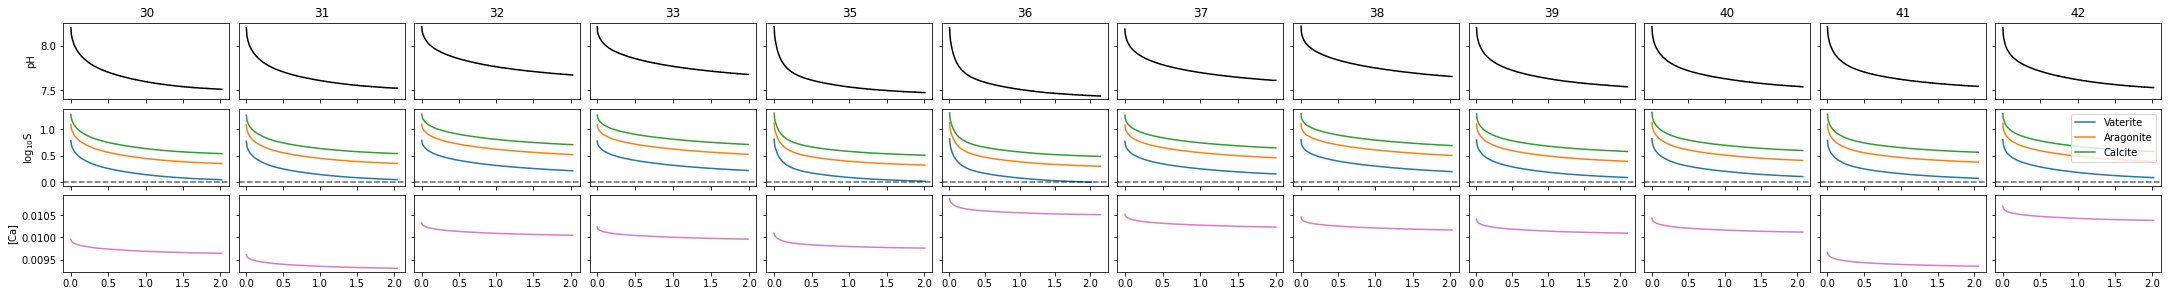

In [147]:
n = len(exps)
fig, axs = plt.subplots(3, n, sharey='row', sharex='col', figsize=[n * 2.5, 4], constrained_layout=True)
if axs.ndim == 1:
    axs = axs.reshape(-1, 1)

for exp, col in zip(exps, axs.T):
    ph, sat, ca = col
    sub = profiles.loc[:, exp]
    
    ph.set_title(exp)
    
    ph.plot('pH', data=sub, color='k')
    
    for phase in ['Vaterite', 'Aragonite', 'Calcite']:
        sat.plot('log10S' + phase[0], data=sub, label=phase)
    
    ca.plot('Ca', data=sub, color='C6', label='Ca')
    sat.axhline(0, ls='--', color='k', alpha=0.6)


axs[0,0].set_ylabel('pH')
axs[1,0].set_ylabel('$log_{10}S$')
axs[2,0].set_ylabel('[Ca]')

axs[1,-1].legend()

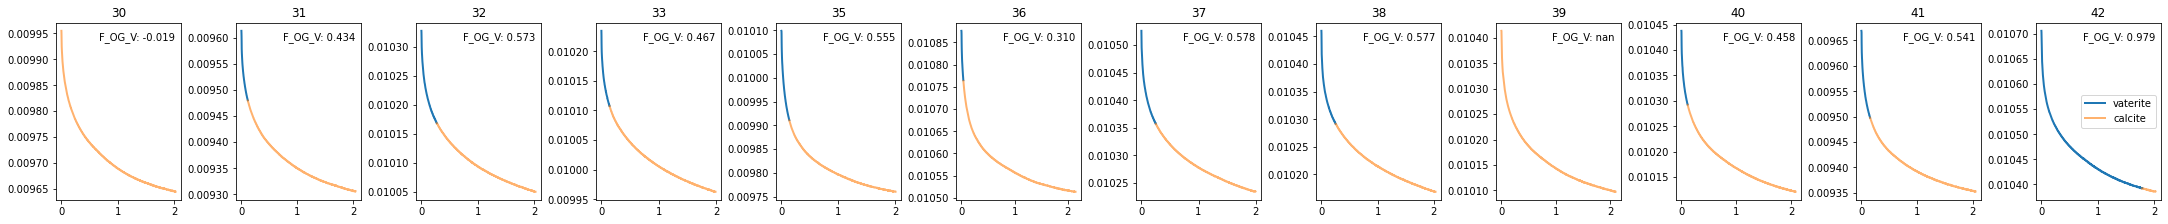

In [148]:
fig, axs = plt.subplots(1, n, sharey=False, sharex='col', figsize=[n * 2.5, 3], constrained_layout=True)

if n == 1:
    axs = [axs]
    
for ax, exp in zip(axs, exps):

    ind = profiles.loc[:, (exp, 'precip_V')]

    ax.plot(profiles.loc[ind].index, profiles.loc[ind, (exp, 'Ca')], color='C0', label='vaterite', lw=2)
    ax.plot(profiles.loc[~ind].index, profiles.loc[~ind, (exp, 'Ca')], color='C1', label='calcite', lw=2, alpha=0.6)
    ax.set_title(exp)
    f_og_v = noms(compositions.loc[int(exp), ('overgrowth', 'F_V')]).item()
    ax.text(.95, .95, f'F_OG_V: {f_og_v:.3f}', ha='right', va='top', transform=ax.transAxes)
axs[-1].legend(loc='center right')

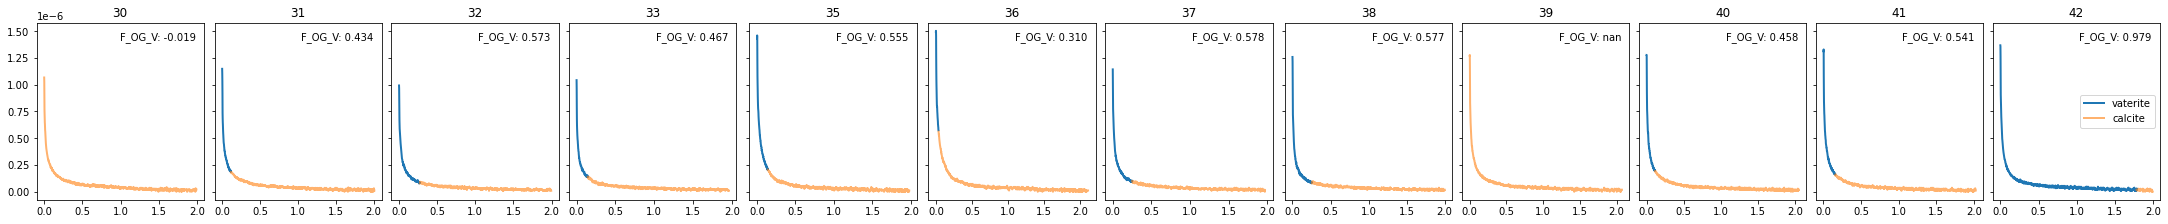

In [149]:
fig, axs = plt.subplots(1, n, sharey='row', sharex='col', figsize=[n * 2.5, 3], constrained_layout=True)

if n == 1:
    axs = [axs]
    
for ax, exp in zip(axs, exps):

    ind = profiles.loc[:, (exp, 'precip_V')]

    ax.plot(profiles.loc[ind].index, profiles.loc[ind, (exp, 'R')], color='C0', label='vaterite', lw=2)
    ax.plot(profiles.loc[~ind].index, profiles.loc[~ind, (exp, 'R')], color='C1', label='calcite', lw=2, alpha=0.6)
    ax.set_title(exp)
    f_og_v = noms(compositions.loc[int(exp), ('overgrowth', 'F_V')]).item()
    ax.text(.95, .95, f'F_OG_V: {f_og_v:.3f}', ha='right', va='top', transform=ax.transAxes)
axs[-1].legend(loc='center right')

In [150]:
from sklearn.metrics import r2_score

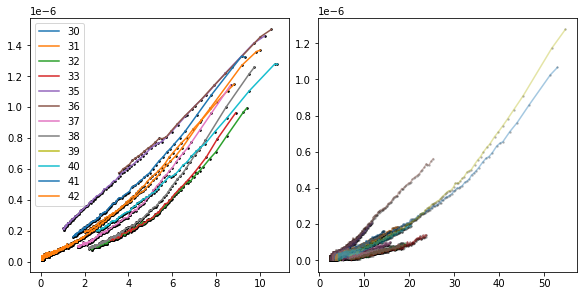

In [151]:
fig, axs = plt.subplots(1, 2, figsize=[8, 4], constrained_layout=True)

vfits_sp = {}
cfits_sp = {}

for exp in exps:
    if exp == '21':
        continue
    ind = profiles.loc[:, (exp, 'precip_V')]

    x = (profiles.loc[ind, (exp, 'SV')] - 1) * np.log(profiles.loc[ind, (exp, 'SV')])
    axs[0].scatter(x, profiles.loc[ind, (exp, 'R')], marker='.', color='k', s=10)
    line = axs[0].plot(x, profiles.loc[ind, (exp, 'R')], label=exp)
    
    # line of best fit
    isna = np.isnan(x)
    if sum(isna) > 2:
        p = np.polyfit(x[~isna], profiles.loc[ind, (exp, 'R')].values[~isna], 1)
        pred = np.polyval(p, x[~isna])
        vfits_sp[exp] = (p, r2_score(profiles.loc[ind, (exp, 'R')].values[~isna], pred))
    
    ind = ~profiles.loc[:, (exp, 'precip_V')]
    # x = (profiles.loc[ind, (exp, 'SV')] - 1) * np.log(profiles.loc[ind, (exp, 'SV')])
    # axs[0].plot(x, profiles.loc[ind, (exp, 'R')], color=line[0].get_color(), alpha=0.4)

    x = (profiles.loc[ind, (exp, 'SC')] - 1) * np.log(profiles.loc[ind, (exp, 'SC')])
    axs[1].plot(x, profiles.loc[ind, (exp, 'R')], color=line[0].get_color(), alpha=0.4)
    axs[1].scatter(x, profiles.loc[ind, (exp, 'R')], marker='.', color='k', s=10, alpha=0.2)
    
    # line of best fit
    isna = np.isnan(x) | np.isnan(profiles.loc[ind, (exp, 'R')].values)
    if sum(isna) > 2:
        p = np.polyfit(x.values[~isna], profiles.loc[ind, (exp, 'R')].values[~isna], 1)
        pred = np.polyval(p, x[~isna])
        cfits_sp[exp] = (p, r2_score(profiles.loc[ind, (exp, 'R')][~isna], pred))
    
axs[0].legend()

/usr/lib/python3.10/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


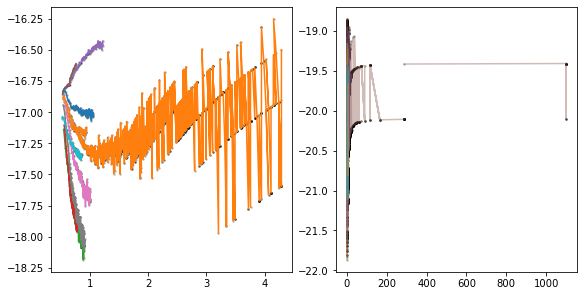

In [152]:
fig, axs = plt.subplots(1, 2, figsize=[8, 4], constrained_layout=True)

vfits_pn = {}
cfits_pn = {}

for exp in exps:
    if exp == '21':
        continue
    ind = profiles.loc[:, (exp, 'precip_V')]

    x = 1 / np.log(profiles.loc[:, (exp, 'SV')])
    SV = profiles.loc[:, (exp, 'SV')]
    F = SV**(7/6) * (SV - 1)**(2/3) * np.log(SV)**(1/6)
    y = np.log(profiles.loc[:, (exp, 'R')] / F)
    
    line = axs[0].plot(x[ind], y[ind])
    axs[0].scatter(x[ind], y[ind], marker='.', color='k', s=10, alpha=0.2)
    
    # line of best fit
    # isna = np.isfinite(x) & np.isfinite(y)
    # p = np.polyfit(x[~isna & ind].values, y[~isna & ind].values, 1)
    # pred = np.polyval(p, x[~isna & ind])
    # vfits_pn[exp] = (p, r2_score(y[~isna & ind], pred))
    
    SC = profiles.loc[:, (exp, 'SC')]
    F = SC**(7/6) * (SC - 1)**(2/3) * np.log(SC)**(1/6)
    y = np.log(profiles.loc[:, (exp, 'R')] / F)
    
    axs[1].plot(x[~ind], y[~ind], color=line[0].get_color(), alpha=0.4)
    axs[1].scatter(x[~ind], y[~ind], marker='.', color='k', s=10, alpha=0.2)
    
    # line of best fit
    # p = np.polyfit(x[~isna & ~ind].values, y[~isna & ~ind].values, 1)
    # pred = np.polyval(p, x[~isna & ~ind])
    # cfits_pn[exp] = (p, r2_score(y[~isna & ~ind], pred))

## TODO

- Fit lines, compare R2 between different mechanisms
- Langmuir constants